In [1]:
!pip install pytorchvideo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.7/132.7 kB 3.0 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 34.1 MB/s eta 0:00:0000:0100:01m
  Created wheel for pytorchvideo: filename=pytorchvideo-0.1.5-py3-none-any.whl size=188686 sha256=ca622f8d2477196901dca3c4b8e52a637e75b1db751412ed1b27d0261c226d45
  Stored in directory: /root/.cache/pip/wheels/b3/49/dc/aab2dce83e38b59849db13a4f4ddd220e568e24b58332fb0f9
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=650cf94b926dad17c2114a58736984ed4d3b537081617d972020c254ae66fdc7
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a1

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import seaborn as sns
import gc

# Performance settings
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:512,expandable_segments:True"

# H100 optimizations: TF32 for matmul/cuDNN (~2-3x faster, negligible accuracy impact)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')

In [3]:
class Normalize:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(-1, 1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1, 1)
    def __call__(self, x):
        return (x - self.mean.to(x.device)) / self.std.to(x.device)

class TwoStreamTransform:
    def __init__(self, flip_prob=0.5):
        self.flip_prob = flip_prob
    def __call__(self, rgb, flow):
        if random.random() < self.flip_prob:
            rgb = np.flip(rgb, axis=2).copy()
            flow = np.flip(flow, axis=2).copy()
            flow[:, :, :, 0] = -flow[:, :, :, 0]
        return rgb, flow

In [4]:
class RWF2000TwoStreamDataset(Dataset):
    def __init__(self, root_dir, transform=None, rgb_transform=None, rgb_norm=None, flow_norm=None):
        self.root_dir = root_dir
        self.classes = ['Fight', 'NonFight']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.samples = []
        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            if os.path.exists(cls_dir):
                for fname in os.listdir(cls_dir):
                    if fname.endswith('.npy'):
                        self.samples.append((os.path.join(cls_dir, fname), self.class_to_idx[cls]))
        self.transform = transform
        self.rgb_transform = rgb_transform
        self.rgb_norm = rgb_norm
        self.flow_norm = flow_norm

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            data = np.load(path).astype(np.float32)
        except:
            data = np.random.rand(16, 224, 224, 5).astype(np.float32)
        rgb = data[..., :3]
        flow = data[..., 3:5]
        if self.transform:
            rgb, flow = self.transform(rgb, flow)
        rgb = rgb / 255.0
        flow = flow / 255.0
        rgb_tensor = torch.from_numpy(rgb).permute(0, 3, 1, 2)
        flow_tensor = torch.from_numpy(flow).permute(0, 3, 1, 2)
        if self.rgb_transform:
            rgb_tensor = self.rgb_transform(rgb_tensor)
        T = rgb_tensor.shape[0]
        slow_idx = np.linspace(0, max(0, T-1), 8).astype(int)
        fast_idx = np.linspace(0, max(0, T-1), 32).astype(int)
        slow_rgb = rgb_tensor[slow_idx].permute(1, 0, 2, 3)
        fast_rgb = rgb_tensor[fast_idx].permute(1, 0, 2, 3)
        slow_flow = flow_tensor[slow_idx].permute(1, 0, 2, 3)
        fast_flow = flow_tensor[fast_idx].permute(1, 0, 2, 3)
        if self.rgb_norm:
            slow_rgb = self.rgb_norm(slow_rgb)
            fast_rgb = self.rgb_norm(fast_rgb)
        if self.flow_norm:
            slow_flow = self.flow_norm(slow_flow)
            fast_flow = self.flow_norm(fast_flow)
        return [slow_rgb, fast_rgb], [slow_flow, fast_flow], torch.tensor(label, dtype=torch.long)

    def get_class_counts(self):
        counts = {0: 0, 1: 0}
        for _, lbl in self.samples:
            counts[lbl] += 1
        return counts

In [5]:
def modify_slowfast_for_flow(model, in_channels=2):
    """Modify both pathway stems to accept flow input"""
    modified = 0
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv3d) and module.in_channels == 3:
            new_conv = nn.Conv3d(
                in_channels,
                module.out_channels,
                kernel_size=module.kernel_size,
                stride=module.stride,
                padding=module.padding,
                bias=module.bias is not None
            )
            with torch.no_grad():
                if in_channels <= 3:
                    new_conv.weight[:, :in_channels] = module.weight[:, :in_channels]
                else:
                    new_conv.weight[:, :3] = module.weight
                    new_conv.weight[:, 3:] = 0
                if module.bias is not None:
                    new_conv.bias.copy_(module.bias)
            parts = name.split('.')
            parent = model
            for p in parts[:-1]:
                parent = getattr(parent, p)
            setattr(parent, parts[-1], new_conv)
            modified += 1
            if modified >= 2:
                break
    return model

class FusionClassifier(nn.Module):
    def __init__(self, rgb_dim, flow_dim, num_classes, dropout_rate=0.5):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(rgb_dim + flow_dim, num_classes)
    def forward(self, rgb_features, flow_features):
        combined = torch.cat([rgb_features, flow_features], dim=1)
        combined = self.dropout(combined)
        return self.fc(combined)

In [6]:
def clear_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

def compute_metrics(labels, preds, probs):
    precision = precision_score(labels, preds, average=None, zero_division=0)
    recall = recall_score(labels, preds, average=None, zero_division=0)
    f1 = f1_score(labels, preds, average=None, zero_division=0)
    fpr, tpr, roc_auc = {}, {}, {}
    for c in [0, 1]:
        f, t, _ = roc_curve(np.array(labels) == c, probs[:, c])
        fpr[c], tpr[c], roc_auc[c] = f, t, auc(f, t)
    return precision, recall, f1, fpr, tpr, roc_auc

In [7]:
def train_epoch(model_rgb, model_flow, fusion, train_loader, criterion, optimizer, device):
    model_rgb.train(); model_flow.train(); fusion.train()
    running_loss = correct = total_samples = 0
    all_preds = []; all_labels = []; all_logits = []
    for batch_idx, (rgb_stream, flow_stream, labels) in enumerate(tqdm(train_loader, desc="Training")):
        slow_r, fast_r = rgb_stream; slow_f, fast_f = flow_stream
        slow_r = slow_r.to(device, non_blocking=True)
        fast_r = fast_r.to(device, non_blocking=True)
        slow_f = slow_f.to(device, non_blocking=True)
        fast_f = fast_f.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        try:
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                rgb_features = model_rgb([slow_r, fast_r])
                flow_features = model_flow([slow_f, fast_f])
                logits = fusion(rgb_features, flow_features)
                loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            preds = logits.argmax(dim=1)
            correct += preds.eq(labels).sum().item()
            total_samples += batch_size
            all_preds.append(preds.detach())
            all_labels.append(labels.detach())
            all_logits.append(logits.detach())
        except RuntimeError as e:
            if "out of memory" in str(e):
                print(f"OOM at batch {batch_idx}, clearing cache...")
                clear_memory()
                continue
            else:
                raise e
    # Batch GPU->CPU transfer at end of epoch (avoids per-batch CUDA sync)
    all_preds = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()
    all_probs = torch.softmax(torch.cat(all_logits).float(), dim=1).cpu().numpy()
    return running_loss/total_samples, correct/total_samples, all_labels, all_preds, all_probs

def validate_epoch(model_rgb, model_flow, fusion, val_loader, criterion, device):
    model_rgb.eval(); model_flow.eval(); fusion.eval()
    val_loss = correct = total_samples = 0
    all_preds = []; all_labels = []; all_logits = []
    with torch.inference_mode():
        for batch_idx, (rgb_stream, flow_stream, labels) in enumerate(tqdm(val_loader, desc="Validation")):
            slow_r, fast_r = rgb_stream; slow_f, fast_f = flow_stream
            slow_r = slow_r.to(device, non_blocking=True)
            fast_r = fast_r.to(device, non_blocking=True)
            slow_f = slow_f.to(device, non_blocking=True)
            fast_f = fast_f.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            try:
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    rgb_features = model_rgb([slow_r, fast_r])
                    flow_features = model_flow([slow_f, fast_f])
                    logits = fusion(rgb_features, flow_features)
                    loss = criterion(logits, labels)
                batch_size = labels.size(0)
                val_loss += loss.item() * batch_size
                preds = logits.argmax(dim=1)
                correct += preds.eq(labels).sum().item()
                total_samples += batch_size
                all_preds.append(preds.detach())
                all_labels.append(labels.detach())
                all_logits.append(logits.detach())
            except RuntimeError as e:
                if "out of memory" in str(e):
                    print(f"OOM in validation at batch {batch_idx}")
                    clear_memory()
                    continue
                else:
                    raise e
    all_preds = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()
    all_probs = torch.softmax(torch.cat(all_logits).float(), dim=1).cpu().numpy()
    return val_loss/total_samples, correct/total_samples, all_labels, all_preds, all_probs

In [8]:
def plot_training_metrics(metrics):
    epochs = range(1, len(metrics['train_loss']) + 1)
    classes = ['Fight', 'NonFight']
    plt.figure(figsize=(15, 15))
    plt.subplot(4, 2, 1)
    plt.plot(epochs, metrics['train_loss'], label='Train Loss')
    plt.plot(epochs, metrics['val_loss'], label='Val Loss')
    plt.legend(); plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.subplot(4, 2, 2)
    plt.plot(epochs, metrics['train_acc'], label='Train Acc')
    plt.plot(epochs, metrics['val_acc'], label='Val Acc')
    plt.legend(); plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.subplot(4, 2, 3)
    for c in range(2):
        plt.plot(epochs, metrics['train_precision'][c], label=f'Train Prec {classes[c]}')
        plt.plot(epochs, metrics['val_precision'][c], label=f'Val Prec {classes[c]}')
    plt.legend(); plt.title('Precision'); plt.xlabel('Epoch'); plt.ylabel('Precision')
    plt.subplot(4, 2, 4)
    for c in range(2):
        plt.plot(epochs, metrics['train_recall'][c], label=f'Train Rec {classes[c]}')
        plt.plot(epochs, metrics['val_recall'][c], label=f'Val Rec {classes[c]}')
    plt.legend(); plt.title('Recall'); plt.xlabel('Epoch'); plt.ylabel('Recall')
    plt.subplot(4, 2, 5)
    for c in range(2):
        plt.plot(epochs, metrics['train_f1'][c], label=f'Train F1 {classes[c]}')
        plt.plot(epochs, metrics['val_f1'][c], label=f'Val F1 {classes[c]}')
    plt.legend(); plt.title('F1 Score'); plt.xlabel('Epoch'); plt.ylabel('F1 Score')
    plt.subplot(4, 2, 6)
    for c in range(2):
        fpr = metrics['train_fpr'][c][-1]; tpr = metrics['train_tpr'][c][-1]
        aucv = metrics['train_roc_auc'][c][-1]
        plt.plot(fpr, tpr, label=f'Train ROC {classes[c]} (AUC={aucv:.2f})')
        fprv = metrics['val_fpr'][c][-1]; tprv = metrics['val_tpr'][c][-1]
        aucvv= metrics['val_roc_auc'][c][-1]
        plt.plot(fprv, tprv, label=f'Val ROC {classes[c]} (AUC={aucvv:.2f})')
    plt.plot([0, 1], [0, 1], 'k--'); plt.legend(); plt.title('ROC Curves (Last Epoch)')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.subplot(4, 2, 7)
    if 'learning_rates' in metrics:
        plt.plot(epochs, metrics['learning_rates'])
        plt.title('Learning Rate'); plt.xlabel('Epoch'); plt.ylabel('Learning Rate')
    else:
        plt.text(0.5, 0.5, 'Learning Rate\nNot Tracked', ha='center', va='center', transform=plt.gca().transAxes)
    plt.subplot(4, 2, 8)
    for c in range(2):
        plt.plot(epochs, metrics['train_roc_auc'][c], label=f'Train AUC {classes[c]}')
        plt.plot(epochs, metrics['val_roc_auc'][c], label=f'Val AUC {classes[c]}')
    plt.legend(); plt.title('AUC Scores'); plt.xlabel('Epoch'); plt.ylabel('AUC')
    plt.tight_layout(); plt.show()

def plot_validation_metrics(fpr, tpr, roc_auc, cm, classes):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for c in range(len(classes)):
        plt.plot(fpr[c], tpr[c], label=f'{classes[c]} (AUC={roc_auc[c]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--'); plt.legend(loc='lower right')
    plt.title('Final Validation ROC Curves'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.subplot(1, 2, 2)
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Normalized Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout(); plt.show()

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
clear_memory()

rgb_norm = Normalize([0.45]*3, [0.225]*3)
flow_norm = Normalize([0.5]*2, [0.5]*2)
rgb_transform = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.GaussianBlur(3, (0.1, 2.0)),
])

train_dataset = RWF2000TwoStreamDataset(
    root_dir='/kaggle/input/rwf2000-opt-rgb/npy/train',
    transform=TwoStreamTransform(0.5),
    rgb_transform=rgb_transform,
    rgb_norm=rgb_norm,
    flow_norm=flow_norm
)
val_dataset = RWF2000TwoStreamDataset(
    root_dir='/kaggle/input/rwf2000-opt-rgb/npy/val',
    transform=None,
    rgb_transform=None,
    rgb_norm=rgb_norm,
    flow_norm=flow_norm
)
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

batch_size = 24  # H100 80GB handles this easily (was 8)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8,
                          pin_memory=True, persistent_workers=True, prefetch_factor=3, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=8,
                        pin_memory=True, persistent_workers=True, prefetch_factor=3)

print("Loading models...")
model_rgb = torch.hub.load('facebookresearch/pytorchvideo', 'slowfast_r50', pretrained=True)
model_flow = torch.hub.load('facebookresearch/pytorchvideo', 'slowfast_r50', pretrained=True)
model_flow = modify_slowfast_for_flow(model_flow, in_channels=2)
model_rgb.blocks[6].proj = nn.Identity()
model_flow.blocks[6].proj = nn.Identity()
model_rgb = model_rgb.to(device)
model_flow = model_flow.to(device)
fusion = FusionClassifier(2304, 2304, 2).to(device)

# torch.compile: fuses CUDA kernels, reduces launch overhead (first epoch slower due to compilation)
if hasattr(torch, 'compile'):
    try:
        print("Compiling models with torch.compile (first epoch will be slower)...")
        model_rgb = torch.compile(model_rgb)
        model_flow = torch.compile(model_flow)
    except Exception as e:
        print(f"torch.compile unavailable ({e}), continuing without compilation.")

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model_rgb = nn.DataParallel(model_rgb)
    model_flow = nn.DataParallel(model_flow)
    fusion = nn.DataParallel(fusion)

class_counts = train_dataset.get_class_counts()
total_samples = sum(class_counts.values())
class_weights = torch.tensor([
    total_samples / (2 * class_counts[0]),
    total_samples / (2 * class_counts[1])
], device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(
    list(model_rgb.parameters()) + list(model_flow.parameters()) + list(fusion.parameters()),
    lr=1e-4, weight_decay=1e-4, fused=True  # fused: single CUDA kernel for optimizer step
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
# BF16 has same dynamic range as FP32 - no GradScaler needed (unlike FP16)

Using device: cuda
GPU: NVIDIA H100 80GB HBM3
GPU memory: 85.0 GB
Train samples: 1601, Val samples: 400
Loading models...
Downloading: "https://github.com/facebookresearch/pytorchvideo/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/pytorchvideo/model_zoo/kinetics/SLOWFAST_8x8_R50.pyth" to /root/.cache/torch/hub/checkpoints/SLOWFAST_8x8_R50.pyth


100%|██████████| 264M/264M [00:01<00:00, 205MB/s]  
Using cache found in /root/.cache/torch/hub/facebookresearch_pytorchvideo_main


Compiling models with torch.compile (first epoch will be slower)...


In [10]:
metrics = {
    'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
    'train_precision': {0: [], 1: []}, 'val_precision': {0: [], 1: []},
    'train_recall': {0: [], 1: []}, 'val_recall': {0: [], 1: []},
    'train_f1': {0: [], 1: []}, 'val_f1': {0: [], 1: []},
    'train_fpr': {0: [], 1: []}, 'val_fpr': {0: [], 1: []},
    'train_tpr': {0: [], 1: []}, 'val_tpr': {0: [], 1: []},
    'train_roc_auc': {0: [], 1: []}, 'val_roc_auc': {0: [], 1: []},
    'learning_rates': []
}
best_val_acc = 0.0
patience = 10
patience_counter = 0
num_epochs = 50

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    train_loss, train_acc, train_labels, train_preds, train_probs = train_epoch(
        model_rgb, model_flow, fusion, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc, val_labels, val_preds, val_probs = validate_epoch(
        model_rgb, model_flow, fusion, val_loader, criterion, device
    )
    train_precision, train_recall, train_f1, train_fpr, train_tpr, train_roc_auc = compute_metrics(
        train_labels, train_preds, train_probs
    )
    val_precision, val_recall, val_f1, val_fpr, val_tpr, val_roc_auc = compute_metrics(
        val_labels, val_preds, val_probs
    )
    metrics['train_loss'].append(train_loss)
    metrics['val_loss'].append(val_loss)
    metrics['train_acc'].append(train_acc)
    metrics['val_acc'].append(val_acc)
    metrics['learning_rates'].append(scheduler.get_last_lr()[0])
    for c in [0, 1]:
        metrics['train_precision'][c].append(train_precision[c])
        metrics['train_recall'][c].append(train_recall[c])
        metrics['train_f1'][c].append(train_f1[c])
        metrics['val_precision'][c].append(val_precision[c])
        metrics['val_recall'][c].append(val_recall[c])
        metrics['val_f1'][c].append(val_f1[c])
        metrics['train_fpr'][c].append(train_fpr[c])
        metrics['train_tpr'][c].append(train_tpr[c])
        metrics['train_roc_auc'][c].append(train_roc_auc[c])
        metrics['val_fpr'][c].append(val_fpr[c])
        metrics['val_tpr'][c].append(val_tpr[c])
        metrics['val_roc_auc'][c].append(val_roc_auc[c])
    print(f"Epoch {epoch + 1} | Train loss {train_loss:.4f} acc {train_acc:.4f} | Val loss {val_loss:.4f} acc {val_acc:.4f}")
    classes = ['Fight', 'NonFight']
    for i, cls in enumerate(classes):
        print(f"{cls} - Train: P={train_precision[i]:.3f}, R={train_recall[i]:.3f}, F1={train_f1[i]:.3f}, AUC={train_roc_auc[i]:.3f}")
        print(f"{cls} - Val:   P={val_precision[i]:.3f}, R={val_recall[i]:.3f}, F1={val_f1[i]:.3f}, AUC={val_roc_auc[i]:.3f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_rgb': model_rgb.module.state_dict() if isinstance(model_rgb, nn.DataParallel) else model_rgb.state_dict(),
            'model_flow': model_flow.module.state_dict() if isinstance(model_flow, nn.DataParallel) else model_flow.state_dict(),
            'fusion': fusion.module.state_dict() if isinstance(fusion, nn.DataParallel) else fusion.state_dict(),
            'optimizer': optimizer.state_dict(),
            'val_acc': val_acc,
            'metrics': metrics
        }, 'best_model.pth')
        patience_counter = 0
        print(f"New best model saved! Val Acc: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered!")
            break
    scheduler.step()
    gc.collect()


Epoch 1/50


Validation: 100%|██████████| 17/17 [01:24<00:00,  4.99s/it]


Epoch 1 | Train loss 0.4792 acc 0.8119 | Val loss 0.4213 acc 0.8625
Fight - Train: P=0.810, R=0.816, F1=0.813, AUC=0.900
Fight - Val:   P=0.962, R=0.755, F1=0.846, AUC=0.967
NonFight - Train: P=0.814, R=0.808, F1=0.811, AUC=0.900
NonFight - Val:   P=0.798, R=0.970, F1=0.876, AUC=0.967
New best model saved! Val Acc: 0.8625

Epoch 2/50


Validation: 100%|██████████| 17/17 [00:14<00:00,  1.14it/s]


Epoch 2 | Train loss 0.3088 acc 0.9451 | Val loss 0.3326 acc 0.9250
Fight - Train: P=0.951, R=0.938, F1=0.945, AUC=0.985
Fight - Val:   P=0.943, R=0.905, F1=0.923, AUC=0.976
NonFight - Train: P=0.939, R=0.952, F1=0.945, AUC=0.985
NonFight - Val:   P=0.909, R=0.945, F1=0.926, AUC=0.976
New best model saved! Val Acc: 0.9250

Epoch 3/50


...

Epoch 23 | Train loss 0.2016 acc 1.0000 | Val loss 0.3100 acc 0.9325
Fight - Train: P=1.000, R=1.000, F1=1.000, AUC=1.000
Fight - Val:   P=0.930, R=0.935, F1=0.933, AUC=0.981
NonFight - Train: P=1.000, R=1.000, F1=1.000, AUC=1.000
NonFight - Val:   P=0.935, R=0.930, F1=0.932, AUC=0.981

Epoch 24/50


Validation: 100%|██████████| 17/17 [00:15<00:00,  1.11it/s]


Epoch 24 | Train loss 0.2015 acc 1.0000 | Val loss 0.3095 acc 0.9300
Fight - Train: P=1.000, R=1.000, F1=1.000, AUC=1.000
Fight - Val:   P=0.934, R=0.925, F1=0.930, AUC=0.982
NonFight - Train: P=1.000, R=1.000, F1=1.000, AUC=1.000
NonFight - Val:   P=0.926, R=0.935, F1=0.930, AUC=0.982

Epoch 25/50


Validation: 100%|██████████| 17/17 [00:15<00:00,  1.08it/s]

Epoch 25 | Train loss 0.2015 acc 1.0000 | Val loss 0.3072 acc 0.9350
Fight - Train: P=1.000, R=1.000, F1=1.000, AUC=1.000
Fight - Val:   P=0.935, R=0.935, F1=0.935, AUC=0.981
NonFight - Train: P=1.000, R=1.000, F1=1.000, AUC=1.000
NonFight - Val:   P=0.935, R=0.935, F1=0.935, AUC=0.981
Early stopping triggered!


Plotting training metrics...


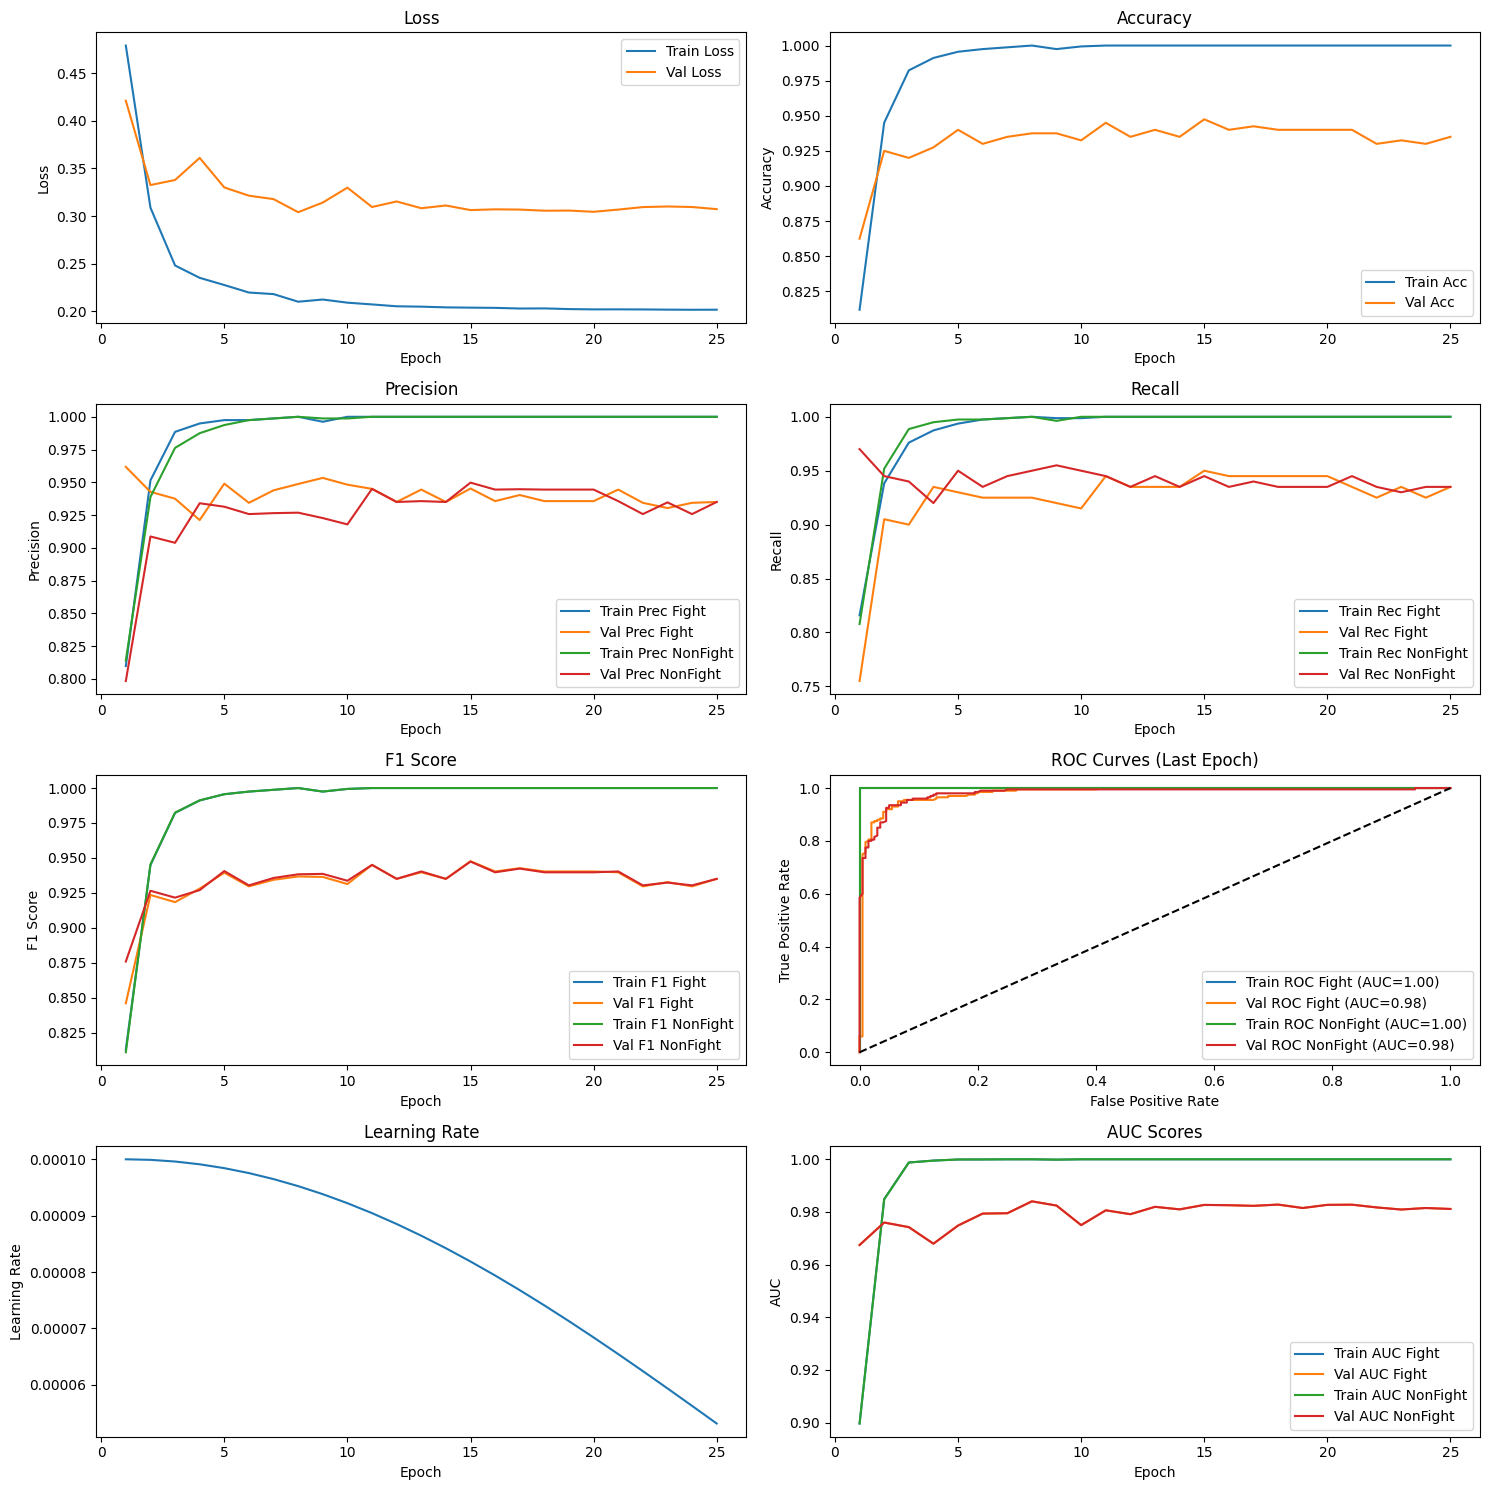

In [11]:
print("Plotting training metrics...")
plot_training_metrics(metrics)


Final validation with best model


Validation: 100%|██████████| 17/17 [00:15<00:00,  1.09it/s]


Final Validation Loss: 0.3063
Final Validation Accuracy: 0.9475

Per-class metrics:
Fight: Precision=0.9453, Recall=0.9500, F1=0.9476, AUC=0.9827
NonFight: Precision=0.9497, Recall=0.9450, F1=0.9474, AUC=0.9827
Plotting final validation metrics...


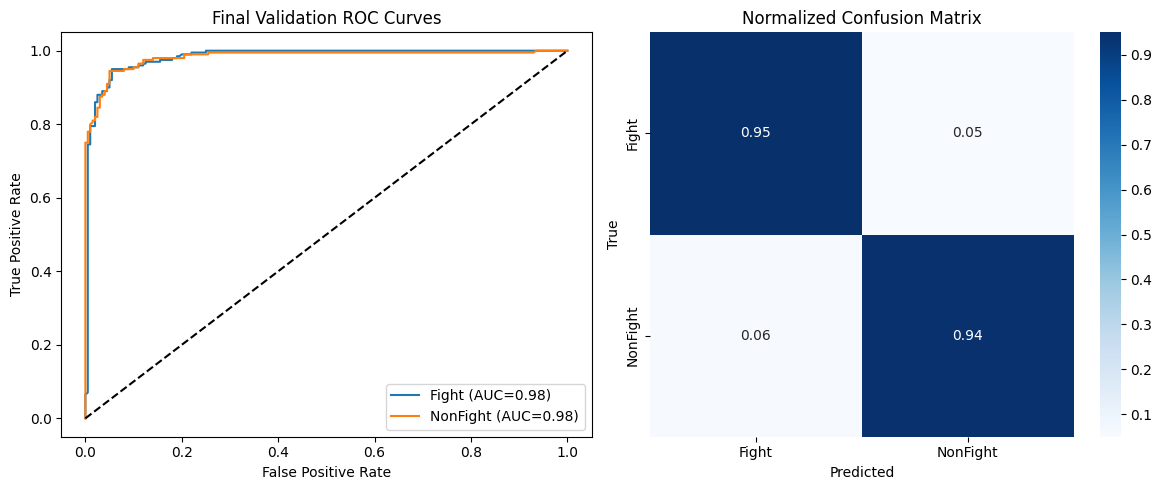

In [13]:
print("\nFinal validation with best model")
checkpoint = torch.load('best_model.pth', map_location=device,weights_only=False)
if isinstance(model_rgb, nn.DataParallel):
    model_rgb.module.load_state_dict(checkpoint['model_rgb'])
    model_flow.module.load_state_dict(checkpoint['model_flow'])
    fusion.module.load_state_dict(checkpoint['fusion'])
else:
    model_rgb.load_state_dict(checkpoint['model_rgb'])
    model_flow.load_state_dict(checkpoint['model_flow'])
    fusion.load_state_dict(checkpoint['fusion'])

final_val_loss, final_val_acc, final_labels, final_preds, final_probs = validate_epoch(
    model_rgb, model_flow, fusion, val_loader, criterion, device
)
final_precision, final_recall, final_f1, final_fpr, final_tpr, final_roc_auc = compute_metrics(
    final_labels, final_preds, final_probs
)
cm = confusion_matrix(final_labels, final_preds, normalize='true')

print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print("\nPer-class metrics:")
classes = ['Fight', 'NonFight']
for i, cls in enumerate(classes):
    print(f"{cls}: Precision={final_precision[i]:.4f}, Recall={final_recall[i]:.4f}, F1={final_f1[i]:.4f}, AUC={final_roc_auc[i]:.4f}")

print("Plotting final validation metrics...")
plot_validation_metrics(final_fpr, final_tpr, final_roc_auc, cm, classes)